In [1]:
import matplotlib.pyplot as plt
import joblib as jlb

from collections import Counter
from sklearn.metrics import silhouette_score
from Algorithm import CLARANS
from Dataprepare.data_processing import D
from Dataprepare.data_processing import data_pca
from utils.Clarans_fast_build import clarans_fast_build

In [10]:
features=[
 'cash_advance',
 'cash_advance_frequency',
 'cash_advance_trx'
]
data=D[features].copy()
print(data.shape)
print(data.tail(1))

(8636, 3)
      cash_advance  cash_advance_frequency  cash_advance_trx
8635       0.42096                1.090332          0.265283


In [ ]:
n_local=5
max_nei=5
k=[i for i in range(2,11)]
silhouette=[]
for i in k:
    test_model=CLARANS(data,i,n_local,max_nei)
    test_model.fit()
    test_model.sihouette_score_=silhouette_score(data,test_model.get_labels())
    silhouette.append(test_model.sihouette_score_)
    print(f'k={i}, Silhouette Score: {test_model.sihouette_score_:.4f}')
plt.figure(figsize=(8,6))
plt.plot(k,silhouette,marker='o')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

k=2, Silhouette Score: 0.7360
k=3, Silhouette Score: 0.7003


KeyboardInterrupt: 

In [11]:
#xay dung model clarans
k = 2
n_local=5
max_nei=5
Clarans_model = CLARANS(data, k, n_local, max_nei)
Clarans_model.fit()

In [12]:
#lấy cluster và medoids
clusters = Clarans_model.get_clusters()
medoids = Clarans_model.get_medoids()

print("Clusters:", clusters)
print("Medoids:", medoids)

Clusters: [[1, 14, 15, 20, 22, 23, 25, 27, 29, 30, 31, 35, 36, 37, 38, 39, 40, 42, 44, 46, 47, 49, 50, 52, 53, 56, 57, 59, 60, 63, 64, 65, 72, 74, 79, 80, 82, 83, 84, 85, 92, 93, 95, 96, 97, 99, 100, 104, 106, 107, 109, 110, 112, 114, 117, 121, 123, 125, 129, 132, 135, 138, 141, 142, 146, 148, 151, 152, 154, 155, 156, 157, 161, 164, 166, 168, 175, 177, 179, 182, 183, 184, 186, 193, 203, 207, 210, 212, 221, 223, 227, 230, 232, 236, 242, 243, 244, 247, 251, 256, 257, 258, 259, 261, 263, 265, 268, 269, 271, 272, 274, 276, 280, 282, 283, 284, 285, 286, 289, 290, 291, 293, 296, 297, 299, 303, 304, 309, 310, 317, 319, 321, 325, 326, 329, 331, 332, 336, 337, 339, 346, 347, 349, 352, 354, 360, 362, 364, 365, 366, 369, 373, 377, 383, 384, 385, 387, 388, 389, 391, 392, 393, 394, 396, 397, 398, 399, 402, 404, 405, 408, 415, 416, 417, 422, 426, 428, 431, 433, 434, 439, 441, 445, 446, 449, 451, 453, 454, 456, 457, 458, 459, 460, 471, 472, 475, 476, 479, 482, 484, 487, 488, 489, 491, 493, 495, 499, 

In [13]:
#gắn nhãn cluster đã có vào df
labels = [0] * len(data)

for cluster_id, cluster in enumerate(clusters):
    for index in cluster:
        labels[index] = cluster_id

data['cluster'] = labels
print(data.head(5))
print('\nKích thước clusters:', Counter(labels))
print('\n2 clusters lớn nhất:', Counter(labels).most_common(2))

   cash_advance  cash_advance_frequency  cash_advance_trx  cluster
0     -0.937894               -0.731226         -0.817000        1
1      1.518315                0.681686          0.768516        0
2     -0.937894               -0.731226         -0.817000        1
3     -0.937894               -0.731226         -0.817000        1
4     -0.937894               -0.731226         -0.817000        1

Kích thước clusters: Counter({1: 4916, 0: 3720})

2 clusters lớn nhất: [(1, 4916), (0, 3720)]


In [14]:
#silhouette score
sil_score = silhouette_score(data.drop(columns=['cluster']), labels)
Clarans_model.sihouette_score_=sil_score
print(f'Silhouette Score: {Clarans_model.sihouette_score_:.4f}')

Silhouette Score: 0.7123


In [15]:
#luu model
jlb.dump(Clarans_model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [16]:
#load model
Loaded_Clarans_model = jlb.load('../customer_clustering/Output/clarans.mdl')

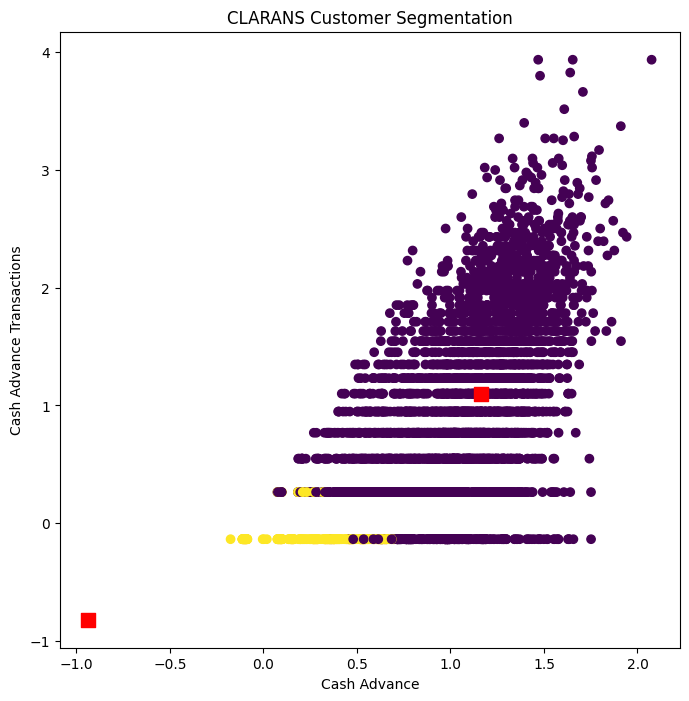

In [17]:
#hien thi model
medoid_points = data.iloc[medoids]

plt.figure(figsize=(8,8))

plt.scatter(data['cash_advance'],
            data['cash_advance_trx'],
            c=data['cluster'])

plt.scatter(medoid_points['cash_advance'],
            medoid_points['cash_advance_trx'],
            marker='s',
            s=100,color='red'
            )

plt.xlabel("Cash Advance")
plt.ylabel("Cash Advance Transactions")
plt.title("CLARANS Customer Segmentation")

plt.show()

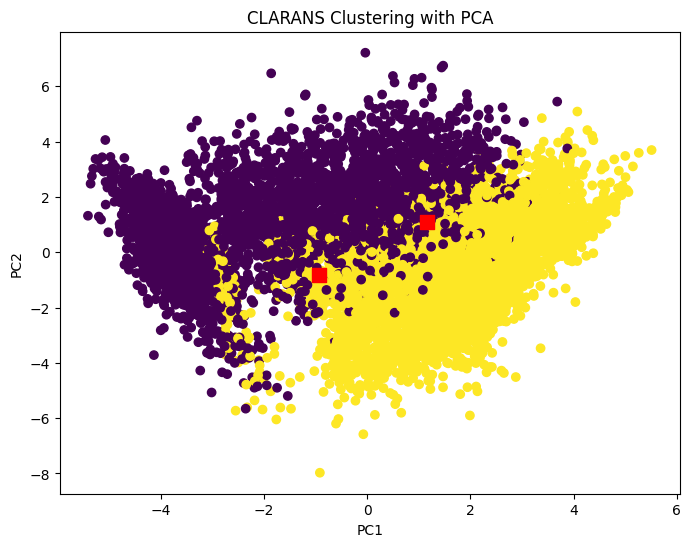

In [18]:
medoid_points = data.iloc[medoids]

plt.figure(figsize=(8,6))
plt.scatter(data_pca[:,0], data_pca[:,1], c=labels)
plt.scatter(medoid_points['cash_advance'],
            medoid_points['cash_advance_trx'],
            marker='s',
            s=100,color='red'
            )
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('CLARANS Clustering with PCA')
plt.show()

Silhouette Score: 0.7288


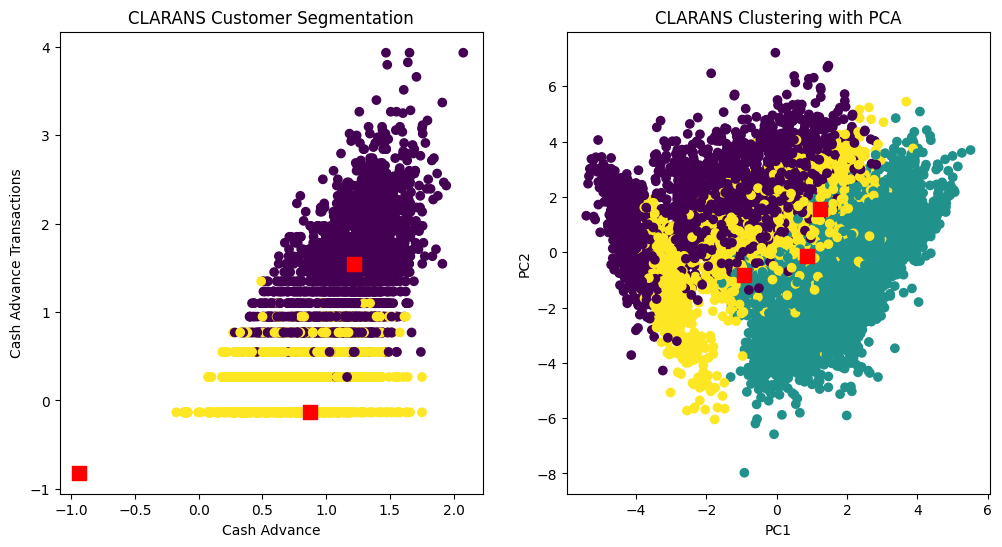

In [3]:
k = 3
n_local=5
max_nei=5
features=[
 'cash_advance',
 'cash_advance_frequency',
 'cash_advance_trx']
datafast=D[features].copy()
clarans_fast_build(datafast,k,n_local,max_nei,'cash_advance','cash_advance_trx',data_pca)